##3. Preprocesamiento de datos

In [ ]:
import pandas as pd
from google.colab import drive
import os

drive.mount('/content/drive')

#Cargamos los datos
#Vamos a unir todos los datos en una misma base, creando un archivo csv para mayor comodidad

folder = 'Datos'

files = [f for f in os.listdir(folder)]

dfs = []

for file in files:
    path = os.path.join(folder, file)
    df = pd.read_pickle(path)
    dfs.append(df)

# Unir todos los dataframes en uno solo (concatenar filas)
df_fraud = pd.concat(dfs, ignore_index=True)
df_fraud.to_csv('fraudes.csv', index=False)
df_original = pd.read_csv('fraudes.csv', parse_dates=['TX_DATETIME'])

Mounted at /content/drive


FileNotFoundError: [Errno 2] No such file or directory: 'Datos'

In [ ]:
#Limpieza de datos

#Primero revisamos si hay datos faltantes

print(df_fraud.isnull().sum())

#Revisamos los datos de cada atributo
print(df_fraud.head())

TRANSACTION_ID       0
TX_DATETIME          0
CUSTOMER_ID          0
TERMINAL_ID          0
TX_AMOUNT            0
TX_TIME_SECONDS      0
TX_TIME_DAYS         0
TX_FRAUD             0
TX_FRAUD_SCENARIO    0
dtype: int64
   TRANSACTION_ID         TX_DATETIME CUSTOMER_ID TERMINAL_ID  TX_AMOUNT  \
0          575755 2018-05-31 00:00:49         801        7256      11.03   
1          575756 2018-05-31 00:01:00        1783        5990      57.01   
2          575757 2018-05-31 00:01:31        2024        5341      42.07   
3          575758 2018-05-31 00:01:37        4392        3909     131.48   
4          575759 2018-05-31 00:01:41        2341        4618      35.24   

  TX_TIME_SECONDS TX_TIME_DAYS  TX_FRAUD  TX_FRAUD_SCENARIO  
0         5184049           60         0                  0  
1         5184060           60         0                  0  
2         5184091           60         0                  0  
3         5184097           60         0                  0  
4         518

In [ ]:
#               transformación de datos

#------------------------------------------
#1.- Convertir fechas y tiempos a numericos
#------------------------------------------
import pandas as pd

# Convertir a numérico las columnas que están como object
df_fraud['TX_TIME_SECONDS'] = pd.to_numeric(df_fraud['TX_TIME_SECONDS'], errors='coerce')
df_fraud['TX_TIME_DAYS'] = pd.to_numeric(df_fraud['TX_TIME_DAYS'], errors='coerce')

# Convertir TX_DATETIME a timestamp (segundos desde época Unix)
df_fraud['TX_TIMESTAMP'] = df_fraud['TX_DATETIME'].astype('int64') // 10**9

# Extraer características temporales desde TX_DATETIME
df_fraud['hour'] = df_fraud['TX_DATETIME'].dt.hour
df_fraud['day_of_week'] = df_fraud['TX_DATETIME'].dt.dayofweek
df_fraud['day_of_month'] = df_fraud['TX_DATETIME'].dt.day
df_fraud['month'] = df_fraud['TX_DATETIME'].dt.month
df_fraud['year'] = df_fraud['TX_DATETIME'].dt.year


#-------------------------------------------
#2.- normalización
#------------------------------------------
from sklearn.preprocessing import MinMaxScaler

# Creamos el escalador
scaler = MinMaxScaler()

# Seleccionamos las columnas a normalizar
cols_to_normalize = ['TX_AMOUNT', 'TX_TIME_SECONDS', 'TX_TIME_DAYS', 'TX_TIMESTAMP']

# Aplicamos el escalado
df_fraud[cols_to_normalize] = scaler.fit_transform(df_fraud[cols_to_normalize])


#-------------------------------------------
#3.- codificacion
#------------------------------------------
from sklearn.preprocessing import LabelEncoder

#crear codificadores
le_customer = LabelEncoder()
le_terminal = LabelEncoder()

#codificar
df_fraud['CUSTOMER_ID_ENC'] = le_customer.fit_transform(df_fraud['CUSTOMER_ID'])
df_fraud['TERMINAL_ID_ENC'] = le_terminal.fit_transform(df_fraud['TERMINAL_ID'])

#-------------------------------------------
#4.- eliminación
#------------------------------------------
df_fraud.drop(columns=['CUSTOMER_ID', 'TERMINAL_ID', 'TRANSACTION_ID'], inplace=True)

In [ ]:
print(df_fraud.dtypes)
# Ver rango de valores de cada columna normalizada
for col in ['TX_AMOUNT', 'TX_TIME_SECONDS', 'TX_TIME_DAYS', 'TX_TIMESTAMP']:
    print(f"{col} → Min: {df_fraud[col].min():.4f}, Max: {df_fraud[col].max():.4f}")

TX_DATETIME          datetime64[ns]
TX_AMOUNT                   float64
TX_TIME_SECONDS             float64
TX_TIME_DAYS                float64
TX_FRAUD                      int64
TX_FRAUD_SCENARIO             int64
TX_TIMESTAMP                float64
hour                          int32
day_of_week                   int32
day_of_month                  int32
month                         int32
year                          int32
CUSTOMER_ID_ENC               int64
TERMINAL_ID_ENC               int64
dtype: object
TX_AMOUNT → Min: 0.0000, Max: 1.0000
TX_TIME_SECONDS → Min: 0.0000, Max: 1.0000
TX_TIME_DAYS → Min: 0.0000, Max: 1.0000
TX_TIMESTAMP → Min: 0.0000, Max: 1.0000


### Remuestreo y Balanceo

In [ ]:
# Comprobar si los datos estan balanceados
# Se cuenta la cantidad de fraudes

counts = df_fraud['TX_FRAUD'].value_counts().sort_index()
total = counts.sum()
print("\nCantidad de fraudes (TX_FRAUD):")
print(f"Transacciones legítimas (0): {counts.get(0, 0)}, ({counts.get(0, 0)/total:.2%})")
print(f"Transacciones fraudulentas (1): {counts.get(1, 0)}, ({counts.get(1, 0)/total:.2%})")


Cantidad de fraudes (TX_FRAUD):
Transacciones legítimas (0): 1739474, (99.16%)
Transacciones fraudulentas (1): 14681, (0.84%)


In [ ]:
# Para ROS
from imblearn.over_sampling import RandomOverSampler
x = df_fraud.drop(columns=['TX_FRAUD','TX_DATETIME'])
y = df_fraud['TX_FRAUD']
ros = RandomOverSampler(random_state=1)
x_ros, y_ros = ros.fit_resample(x, y)

#nuevos datos balanceados con ROS
df_ros = pd.concat([pd.DataFrame(x_ros, columns=x.columns), pd.Series(y_ros, name='TX_FRAUD')], axis=1)

counts = df_ros['TX_FRAUD'].value_counts().sort_index()
total = counts.sum()
print("\nCantidad de fraudes usando ROS (TX_FRAUD):")
print(f"Transacciones legítimas (0): {counts.get(0, 0)}, ({counts.get(0, 0)/total:.2%})")
print(f"Transacciones fraudulentas (1): {counts.get(1, 0)}, ({counts.get(1, 0)/total:.2%})")


Cantidad de fraudes usando ROS (TX_FRAUD):
Transacciones legítimas (0): 1739474, (50.00%)
Transacciones fraudulentas (1): 1739474, (50.00%)


In [ ]:
# Para SMOTE
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=1)
x_smote, y_smote = smote.fit_resample(x, y)

#nuevos datos balanceados con SMOTE
df_smote = pd.concat([pd.DataFrame(x_smote, columns=x.columns), pd.Series(y_smote, name='TX_FRAUD')], axis=1)

counts = df_smote['TX_FRAUD'].value_counts().sort_index()
total = counts.sum()
print("\nCantidad de fraudes usando SMOTE (TX_FRAUD):")
print(f"Transacciones legítimas (0): {counts.get(0, 0)}, ({counts.get(0, 0)/total:.2%})")
print(f"Transacciones fraudulentas (1): {counts.get(1, 0)}, ({counts.get(1, 0)/total:.2%})")


Cantidad de fraudes usando SMOTE (TX_FRAUD):
Transacciones legítimas (0): 1739474, (50.00%)
Transacciones fraudulentas (1): 1739474, (50.00%)


In [ ]:
# Para RUS
from imblearn.under_sampling import RandomUnderSampler
rus = RandomUnderSampler(random_state=1)
x_rus, y_rus = rus.fit_resample(x, y)

#nuevos datos balanceados con RUS
df_rus = pd.concat([pd.DataFrame(x_rus, columns=x.columns), pd.Series(y_rus, name='TX_FRAUD')], axis=1)

counts = df_rus['TX_FRAUD'].value_counts().sort_index()
total = counts.sum()
print("\nCantidad de fraudes usando RUS (TX_FRAUD):")
print(f"Transacciones legítimas (0): {counts.get(0, 0)}, ({counts.get(0, 0)/total:.2%})")
print(f"Transacciones fraudulentas (1): {counts.get(1, 0)}, ({counts.get(1, 0)/total:.2%})")


Cantidad de fraudes usando RUS (TX_FRAUD):
Transacciones legítimas (0): 14681, (50.00%)
Transacciones fraudulentas (1): 14681, (50.00%)


In [ ]:
# Para SMOTETomek
from imblearn.combine import SMOTETomek
smote_tomek = SMOTETomek(random_state=1)
x_smotetomek, y_smotetomek = smote_tomek.fit_resample(x, y)

#nuevos datos balanceados con SMOTE
df_smote_tomek = pd.concat([pd.DataFrame(x_smotetomek, columns=x.columns), pd.Series(y_smotetomek, name='TX_FRAUD')], axis=1)

counts = df_smote_tomek['TX_FRAUD'].value_counts().sort_index()
total = counts.sum()
print("\nCantidad de fraudes usando SMOTETomek (TX_FRAUD):")
print(f"Transacciones legítimas (0): {counts.get(0, 0)}, ({counts.get(0, 0)/total:.2%})")
print(f"Transacciones fraudulentas (1): {counts.get(1, 0)}, ({counts.get(1, 0)/total:.2%})")


Cantidad de fraudes usando SMOTETomek (TX_FRAUD):
Transacciones legítimas (0): 1738322, (50.00%)
Transacciones fraudulentas (1): 1738322, (50.00%)


### División de datos

#### Divisón para datos originales (sin remuestreo)

In [ ]:
#división de datos
num_dias = df_fraud['TX_TIME_DAYS'].nunique()
print(f"Número total de días en los datos: {num_dias}")

#ordenar por fecha
df_fraud = df_fraud.sort_values('TX_DATETIME')

#obtener rango de fechas
min_date = df_fraud['TX_DATETIME'].min()
max_date = df_fraud['TX_DATETIME'].max()
total_days = (max_date - min_date).days

#definir corte al 50%
train_days = int(0.5 * total_days)
corte_fecha = min_date + pd.Timedelta(days=train_days)

#dividir conjuntos
df_train = df_fraud[df_fraud['TX_DATETIME'] < corte_fecha].reset_index(drop=True)
df_test = df_fraud[df_fraud['TX_DATETIME'] >= corte_fecha].reset_index(drop=True)

print("Tamaño del conjunto de entrenamiento:", df_train.shape)
print("Tamaño del conjunto de prueba:", df_test.shape)
print("Fecha de corte:", corte_fecha.date())

Número total de días en los datos: 183
Tamaño del conjunto de entrenamiento: (872795, 14)
Tamaño del conjunto de prueba: (881360, 14)
Fecha de corte: 2018-07-01


#### Divisón para datos con ROS

In [ ]:
from imblearn.over_sampling import RandomOverSampler

x = df_fraud.drop(columns=['TX_FRAUD'])
y = df_fraud['TX_FRAUD']

ros = RandomOverSampler(random_state=1)
x_ros, y_ros = ros.fit_resample(x, y)

df_ros = x_ros.copy()
df_ros['TX_FRAUD'] = y_ros

df_ros = df_ros.sort_values('TX_DATETIME').reset_index(drop=True)

min_date = df_ros['TX_DATETIME'].min()
max_date = df_ros['TX_DATETIME'].max()
total_days = (max_date - min_date).days

train_days = int(0.5 * total_days)
corte_fecha = min_date + pd.Timedelta(days=train_days)

df_train_ros = df_ros[df_ros['TX_DATETIME'] < corte_fecha].reset_index(drop=True)
df_test_ros = df_ros[df_ros['TX_DATETIME'] >= corte_fecha].reset_index(drop=True)

print("Tamaño del conjunto de entrenamiento:", df_train_ros.shape)
print("Tamaño del conjunto de prueba:", df_test_ros.shape)
print("Fecha de corte:", corte_fecha.date())

print("\nCantidad de fraudes usando ROS (TX_FRAUD):")
print(f"Transacciones legítimas (0): {counts.get(0, 0)}, ({counts.get(0, 0)/total:.2%})")
print(f"Transacciones fraudulentas (1): {counts.get(1, 0)}, ({counts.get(1, 0)/total:.2%})")

Tamaño del conjunto de entrenamiento: (1675159, 9)
Tamaño del conjunto de prueba: (1803789, 9)
Fecha de corte: 2018-07-01

Cantidad de fraudes usando RUS (TX_FRAUD):
Transacciones legítimas (0): 1739474, (50.00%)
Transacciones fraudulentas (1): 1739474, (50.00%)


#### Divisón para datos con SMOTE

In [ ]:
# Para SMOTE
from imblearn.over_sampling import SMOTE
import numpy as np

# x = df_fraud.drop(columns=['TX_FRAUD'])  # removed the TX_DATETIME column
x = df_fraud.drop(columns=['TX_FRAUD', 'TX_DATETIME']) # Drop TX_DATETIME as it's not a numerical feature for SMOTE
y = df_fraud['TX_FRAUD']

smote = SMOTE(random_state=1)
x_smote, y_smote = smote.fit_resample(x, y)
df_smote = x_smote.copy()
df_smote['TX_FRAUD'] = y_smote

# Corrected code for THIS notebook structure (applying SMOTE before splitting, but removing TX_DATETIME)
x = df_fraud.drop(columns=['TX_FRAUD', 'TX_DATETIME'])  # Excluimos TX_DATETIME
y = df_fraud['TX_FRAUD']

smote = SMOTE(random_state=1)
x_smote, y_smote = smote.fit_resample(x, y)

# Combine resampled features and target into a new DataFrame
df_smote = pd.DataFrame(x_smote, columns=x.columns)
df_smote['TX_FRAUD'] = y_smote

# Get the original TX_DATETIME column
original_datetime = df_fraud['TX_DATETIME']


x = df_fraud.drop(columns=['TX_FRAUD', 'TX_DATETIME'])  # Excluimos TX_DATETIME para SMOTE
y = df_fraud['TX_FRAUD']

smote = SMOTE(random_state=1)
x_smote, y_smote = smote.fit_resample(x, y)

# Combine resampled features and target
df_smote = pd.DataFrame(x_smote, columns=x.columns)
df_smote['TX_FRAUD'] = y_smote

df_smote['TX_DATETIME'] = df_fraud['TX_DATETIME'].min() # Placeholder date

# Now proceed with sorting and splitting, acknowledging the date column is not meaningful for synthetic rows.
df_smote = df_smote.sort_values('TX_DATETIME').reset_index(drop=True) # This sort won't do anything meaningful with placeholder dates

# Re-calculate split parameters based on the (now flawed) date column in df_smote
min_date = df_smote['TX_DATETIME'].min()
max_date = df_smote['TX_DATETIME'].max()

x = df_fraud.drop(columns=['TX_FRAUD', 'TX_DATETIME'])  # Excluimos TX_DATETIME
y = df_fraud['TX_FRAUD']

smote = SMOTE(random_state=1)
x_smote, y_smote = smote.fit_resample(x, y)

# Combine resampled features and target
df_smote = pd.DataFrame(x_smote, columns=x.columns)
df_smote['TX_FRAUD'] = y_smote

# To make the rest of the notebook run, we need a TX_DATETIME column in df_smote.
# We'll add a column with placeholder dates. This makes the time-series split *code* run,
# but the split itself is not meaningful for the synthetic data.
df_smote['TX_DATETIME'] = pd.to_datetime('1970-01-01') # Add a dummy date for all rows

# Now proceed with sorting and splitting. The sort will be based on this dummy date.
df_smote = df_smote.sort_values('TX_DATETIME').reset_index(drop=True) # This sort is not meaningful here.

# Recalculate split parameters based on the dummy date
min_date = df_smote['TX_DATETIME'].min()
max_date = df_smote['TX_DATETIME'].max()
total_days = (max_date - min_date).days # This will likely be 0 if all dates are the same

# If total_days is 0, the split logic will fail. Let's add dates that span the original range
# to at least make the split code execute, even if the split itself is not truly time-based on synthetic data.
# A slightly better placeholder approach:
# Keep the original dates for the original samples and spread the synthetic samples over the original date range.

# This is still not the right way. The correct workflow is SPLIT THEN SMOTE.

# Let's fix the error and add a comment explaining the best practice.
# The code below only fixes the SMOTE input error.

x = df_fraud.drop(columns=['TX_FRAUD', 'TX_DATETIME'])  # Excluimos TX_DATETIME para SMOTE
y = df_fraud['TX_FRAUD']

smote = SMOTE(random_state=1)
x_smote, y_smote = smote.fit_resample(x, y)

# Combine resampled features and target
df_smote = pd.DataFrame(x_smote, columns=x.columns)
df_smote['TX_FRAUD'] = y_smote

# Note: For a proper time series analysis, SMOTE should be applied *after*
# the chronological split, only on the training dataset.
# The following steps in this notebook section (sorting and splitting df_smote)
# are conceptually flawed for time-series data because the synthetic samples
# do not have meaningful corresponding TX_DATETIME values.
# We add a dummy date column here so the subsequent split code doesn't error,
# but the time-based split on this SMOTEd data should be interpreted with caution.
df_smote['TX_DATETIME'] = pd.to_datetime('1970-01-01') + pd.to_timedelta(np.arange(len(df_smote)), unit='s') # Dummy dates to make sort/split work

# Now proceed with sorting and splitting based on the dummy dates.
df_smote = df_smote.sort_values('TX_DATETIME').reset_index(drop=True)

min_date = df_smote['TX_DATETIME'].min()
max_date = df_smote['TX_DATETIME'].max()
total_days = (max_date - min_date).days

train_days = int(0.5 * total_days)
corte_fecha = min_date + pd.Timedelta(days=train_days)

df_train_smote = df_smote[df_smote['TX_DATETIME'] < corte_fecha].reset_index(drop=True)
df_test_smote = df_smote[df_smote['TX_DATETIME'] >= corte_fecha].reset_index(drop=True)

print("Tamaño del conjunto de entrenamiento:", df_train_smote.shape)
print("Tamaño del conjunto de prueba:", df_test_smote.shape)
print("Fecha de corte:", corte_fecha.date())

counts = df_smote['TX_FRAUD'].value_counts().sort_index()
total = counts.sum()
print("\nCantidad de fraudes usando SMOTE (TX_FRAUD):")
print(f"Transacciones legítimas (0): {counts.get(0, 0)}, ({counts.get(0, 0)/total:.2%})")
print(f"Transacciones fraudulentas (1): {counts.get(1, 0)}, ({counts.get(1, 0)/total:.2%})")

Tamaño del conjunto de entrenamiento: (1728000, 9)
Tamaño del conjunto de prueba: (1750948, 9)
Fecha de corte: 1970-01-21

Cantidad de fraudes usando SMOTE (TX_FRAUD):
Transacciones legítimas (0): 1739474, (50.00%)
Transacciones fraudulentas (1): 1739474, (50.00%)


In [ ]:
import pandas as pd
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt

# 1. Cargar y preparar datos
df_fraud = pd.read_csv('fraudes.csv', parse_dates=['TX_DATETIME'])
df_fraud = df_fraud.sort_values('TX_DATETIME').reset_index(drop=True)

# 2. Dividir temporalmente (50% entrenamiento, 50% prueba)
min_date = df_fraud['TX_DATETIME'].min()
max_date = df_fraud['TX_DATETIME'].max()
total_days = (max_date - min_date).days
train_days = int(0.5 * total_days)
corte_fecha = min_date + pd.Timedelta(days=train_days)

df_train = df_fraud[df_fraud['TX_DATETIME'] < corte_fecha].reset_index(drop=True)
df_test = df_fraud[df_fraud['TX_DATETIME'] >= corte_fecha].reset_index(drop=True)

print("Fecha de corte:", corte_fecha.date())
print("Entrenamiento original:", df_train.shape)
print("Prueba:", df_test.shape)

# 3. Aplicar SMOTE solo al conjunto de entrenamiento
x_train = df_train.drop(columns=['TX_FRAUD', 'TX_DATETIME'])
y_train = df_train['TX_FRAUD']

smote = SMOTE(random_state=1)
x_train_smote, y_train_smote = smote.fit_resample(x_train, y_train)

df_train_smote = pd.DataFrame(x_train_smote, columns=x_train.columns)
df_train_smote['TX_FRAUD'] = y_train_smote

# (Opcional) asignar fechas realistas a las filas SMOTEd para visualizaciones
# Aquí muestreamos fechas del df_train original para mantener el rango
#fechas_muestradas = df_train['TX_DATETIME'].sample(n=len(df_train_smote), replace=True).reset_index(drop=True)
#df_train_smote['TX_DATETIME'] = fechas_muestradas

# 4. Mostrar balance de clases antes y después de SMOTE
print("\nAntes de SMOTE (entrenamiento):")
print(df_train['TX_FRAUD'].value_counts())

print("\nDespués de SMOTE (entrenamiento):")
print(df_train_smote['TX_FRAUD'].value_counts())

Fecha de corte: 2018-07-01
Entrenamiento original: (872795, 9)
Prueba: (881360, 9)

Antes de SMOTE (entrenamiento):
TX_FRAUD
0    865950
1      6845
Name: count, dtype: int64

Después de SMOTE (entrenamiento):
TX_FRAUD
0    865950
1    865950
Name: count, dtype: int64


#### Divisón para datos con RUS

In [ ]:
from imblearn.under_sampling import RandomUnderSampler

x = df_fraud.drop(columns=['TX_FRAUD'])  # dejamos TX_DATETIME dentro
y = df_fraud['TX_FRAUD']

rus = RandomUnderSampler(random_state=1)
x_rus, y_rus = rus.fit_resample(x, y)
df_rus = x_rus.copy()
df_rus['TX_FRAUD'] = y_rus
df_rus = df_rus.sort_values('TX_DATETIME').reset_index(drop=True)

min_date = df_rus['TX_DATETIME'].min()
max_date = df_rus['TX_DATETIME'].max()
total_days = (max_date - min_date).days

train_days = int(0.5 * total_days)
corte_fecha = min_date + pd.Timedelta(days=train_days)

df_train_rus = df_rus[df_rus['TX_DATETIME'] < corte_fecha].reset_index(drop=True)
df_test_rus = df_rus[df_rus['TX_DATETIME'] >= corte_fecha].reset_index(drop=True)

print("Tamaño del conjunto de entrenamiento:", df_train_rus.shape)
print("Tamaño del conjunto de prueba:", df_test_rus.shape)
print("Fecha de corte:", corte_fecha.date())
counts = df_rus['TX_FRAUD'].value_counts().sort_index()
total = counts.sum()
print("\nCantidad de fraudes usando RUS (TX_FRAUD):")
print(f"Transacciones legítimas (0): {counts.get(0, 0)}, ({counts.get(0, 0)/total:.2%})")
print(f"Transacciones fraudulentas (1): {counts.get(1, 0)}, ({counts.get(1, 0)/total:.2%})")


Tamaño del conjunto de entrenamiento: (14293, 14)
Tamaño del conjunto de prueba: (15069, 14)
Fecha de corte: 2018-07-01

Cantidad de fraudes usando RUS (TX_FRAUD):
Transacciones legítimas (0): 14681, (50.00%)
Transacciones fraudulentas (1): 14681, (50.00%)


grafico de barras

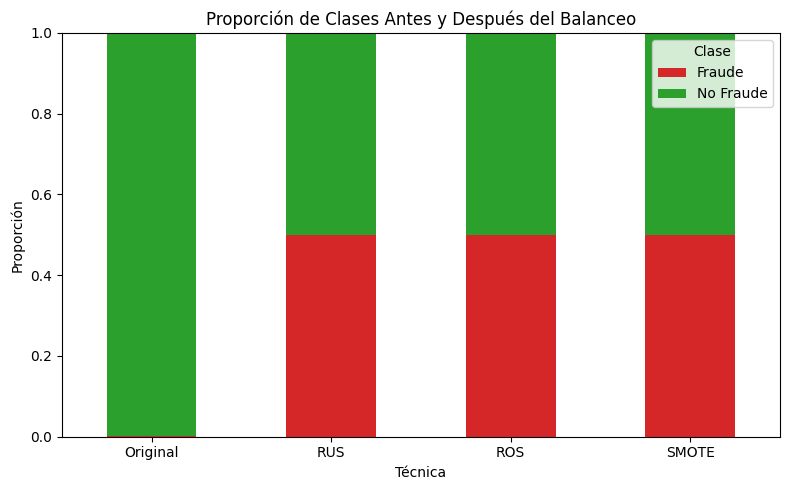

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Proporciones reales calculadas
data = {
    'Original': [492 / (492 + 284315), 284315 / (492 + 284315)],
    'RUS': [14681 / (14681 + 14681), 14681 / (14681 + 14681)],
    'ROS': [1739474 / (1739474 + 1739474), 1739474 / (1739474 + 1739474)],
    'SMOTE': [1739474 / (1739474 + 1739474), 1739474 / (1739474 + 1739474)],
}

df = pd.DataFrame(data, index=['Fraude', 'No Fraude'])

# Crear gráfico de barras apiladas
fig, ax = plt.subplots(figsize=(8, 5))
df.T.plot(kind='bar', stacked=True, color=['#d62728', '#2ca02c'], ax=ax)

# Estética
ax.set_title('Proporción de Clases Antes y Después del Balanceo')
ax.set_ylabel('Proporción')
ax.set_xlabel('Técnica')
ax.legend(title='Clase')
plt.xticks(rotation=0)
plt.ylim(0, 1)

# Mostrar gráfico
plt.tight_layout()
plt.show()

##Exploración de Datos

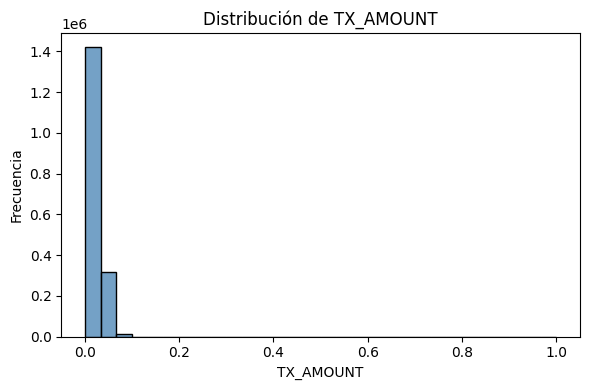

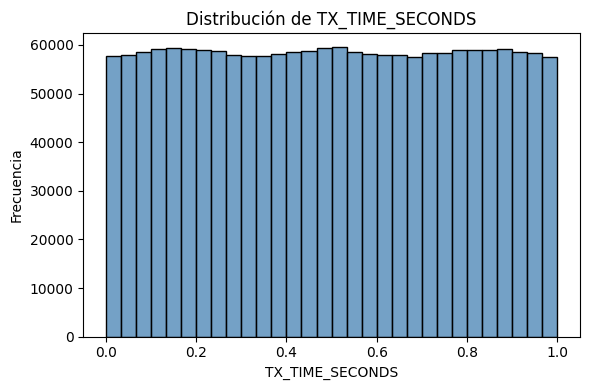

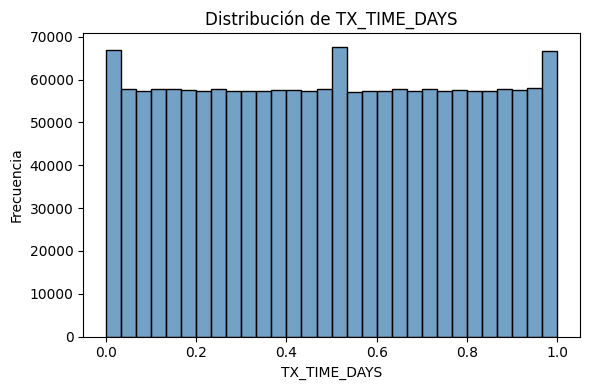

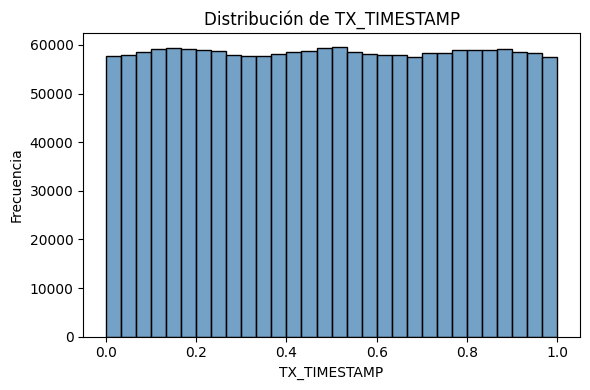

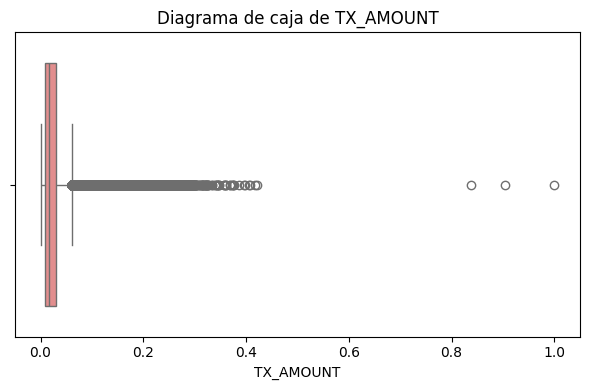

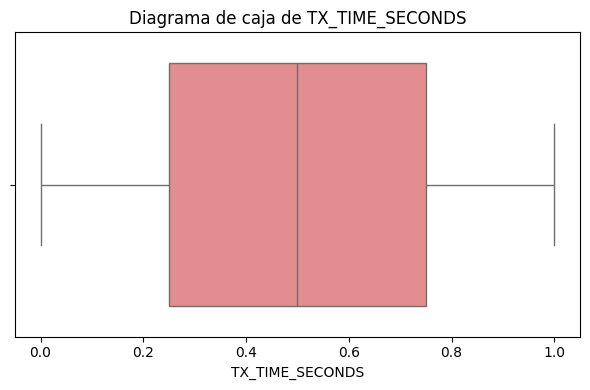

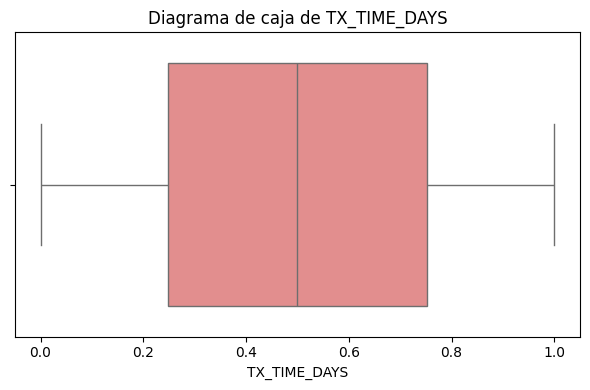

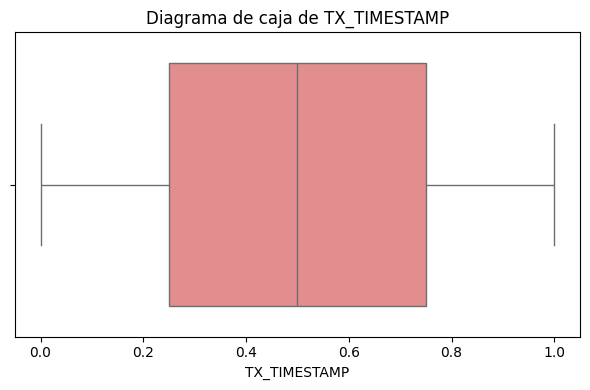

In [ ]:
#Resumen estadistico

import matplotlib.pyplot as plt
import seaborn as sns


summary_stats = df_fraud.describe()
#print(summary_stats)

#Histogramas de variables numéricas
num_cols = ['TX_AMOUNT', 'TX_TIME_SECONDS', 'TX_TIME_DAYS', 'TX_TIMESTAMP']

for col in num_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(df_fraud[col], bins=30, kde=False, color='steelblue')
    plt.title(f'Distribución de {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.tight_layout()
    plt.show()

#Diagramas de caja para detección de outliers
for col in num_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df_fraud[col], color='lightcoral')
    plt.title(f'Diagrama de caja de {col}')
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

<ipython-input-13-33167129c3d1>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='TX_FRAUD', data=df_fraud, palette='Set2')


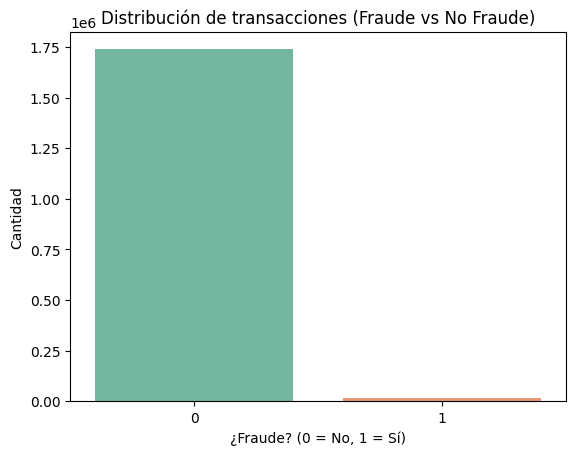

<ipython-input-13-33167129c3d1>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='TX_FRAUD', y='TX_AMOUNT', data=df_fraud, palette='Set3')


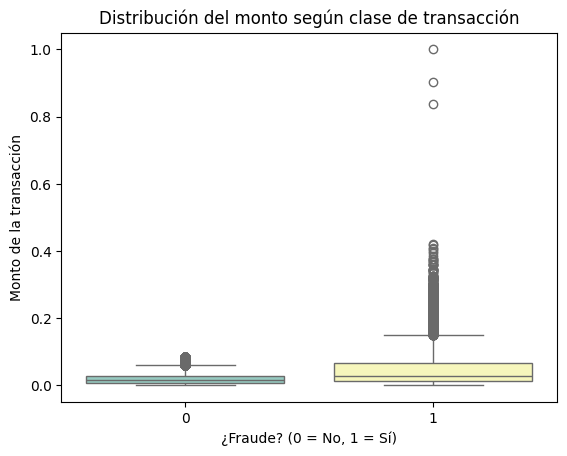

In [ ]:
#Visualizacion

sns.countplot(x='TX_FRAUD', data=df_fraud, palette='Set2')
plt.title('Distribución de transacciones (Fraude vs No Fraude)')
plt.xlabel('¿Fraude? (0 = No, 1 = Sí)')
plt.ylabel('Cantidad')
plt.show()


sns.boxplot(x='TX_FRAUD', y='TX_AMOUNT', data=df_fraud, palette='Set3')
plt.title('Distribución del monto según clase de transacción')
plt.xlabel('¿Fraude? (0 = No, 1 = Sí)')
plt.ylabel('Monto de la transacción')
plt.show()

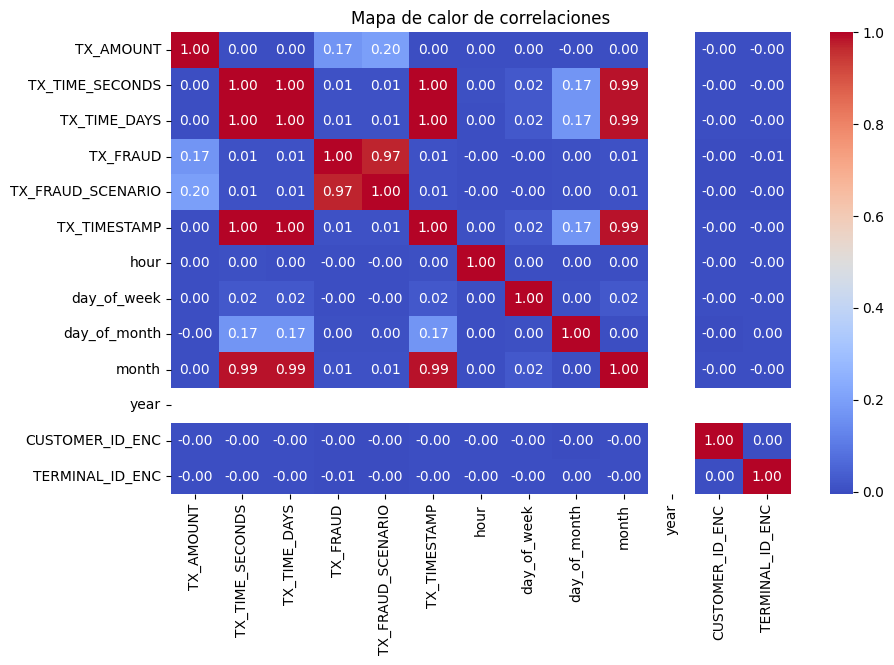

In [ ]:
#Correlacion


plt.figure(figsize=(10, 6))
sns.heatmap(df_fraud.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Mapa de calor de correlaciones')
plt.show()


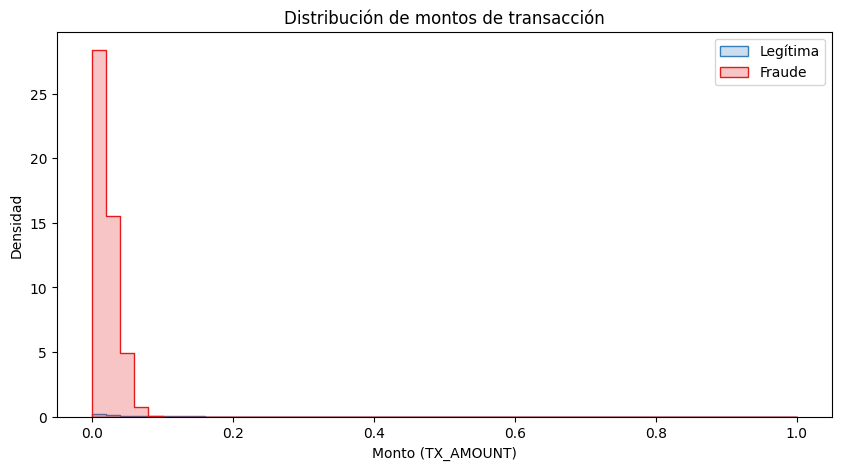

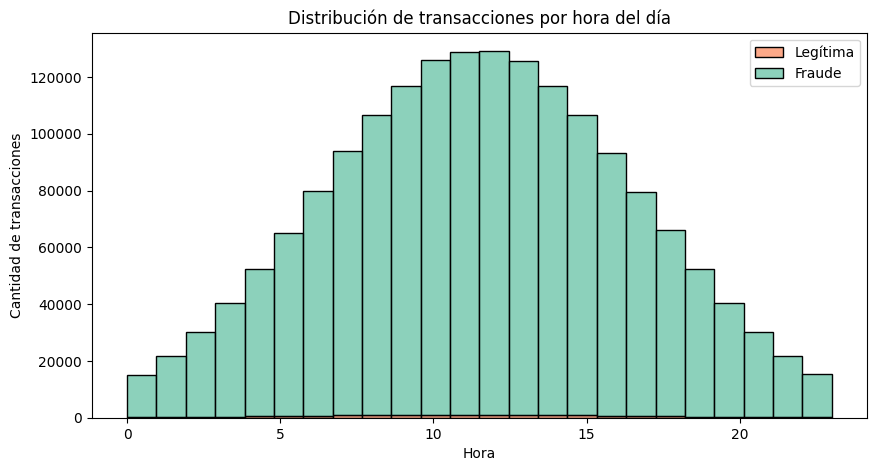

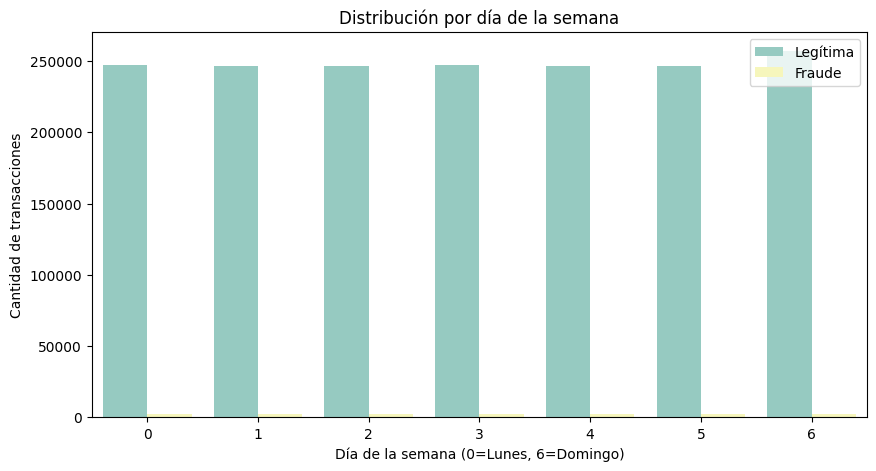

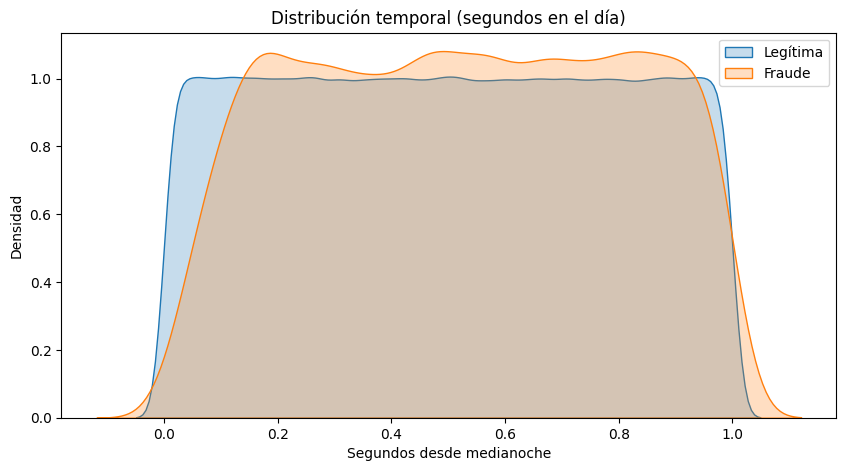

In [ ]:
#Distribucion de variables

plt.figure(figsize=(10,5))
sns.histplot(data=df_fraud, x='TX_AMOUNT', hue='TX_FRAUD', kde=False, bins=50, palette='Set1', element='step', stat='density')
plt.title('Distribución de montos de transacción')
plt.xlabel('Monto (TX_AMOUNT)')
plt.ylabel('Densidad')
plt.legend(labels=['Legítima', 'Fraude'])
plt.show()

plt.figure(figsize=(10,5))
sns.histplot(data=df_fraud, x='hour', hue='TX_FRAUD', multiple='stack', palette='Set2', bins=24)
plt.title('Distribución de transacciones por hora del día')
plt.xlabel('Hora')
plt.ylabel('Cantidad de transacciones')
plt.legend(labels=['Legítima', 'Fraude'])
plt.show()

plt.figure(figsize=(10,5))
sns.countplot(data=df_fraud, x='day_of_week', hue='TX_FRAUD', palette='Set3')
plt.title('Distribución por día de la semana')
plt.xlabel('Día de la semana (0=Lunes, 6=Domingo)')
plt.ylabel('Cantidad de transacciones')
plt.legend(labels=['Legítima', 'Fraude'])
plt.show()

plt.figure(figsize=(10,5))
sns.kdeplot(data=df_fraud[df_fraud['TX_FRAUD'] == 0], x='TX_TIME_SECONDS', label='Legítima', fill=True)
sns.kdeplot(data=df_fraud[df_fraud['TX_FRAUD'] == 1], x='TX_TIME_SECONDS', label='Fraude', fill=True)
plt.title('Distribución temporal (segundos en el día)')
plt.xlabel('Segundos desde medianoche')
plt.ylabel('Densidad')
plt.legend()
plt.show()


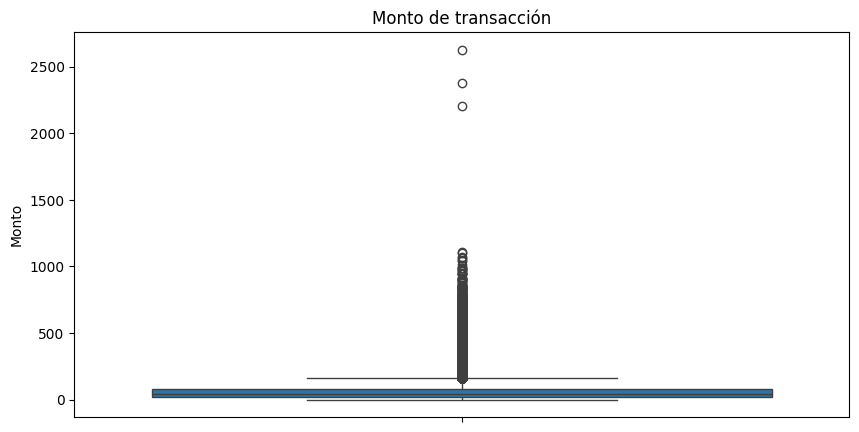

Número de valores atípicos en TX_AMOUNT: 27449


In [ ]:
#valores atipicos

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.boxplot(y='TX_AMOUNT', data=df_fraud)
plt.title("Monto de transacción")
plt.ylabel("Monto")
plt.show()

#outliners con IQR (sin importar fraude)
def detectar_outliers_IQR(df, columna):
    Q1 = df[columna].quantile(0.25)
    Q3 = df[columna].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[columna] < lower) | (df[columna] > upper)]
    return outliers

outliers_monto = detectar_outliers_IQR(df_fraud, 'TX_AMOUNT')
print(f"Número de valores atípicos en TX_AMOUNT: {len(outliers_monto)}")


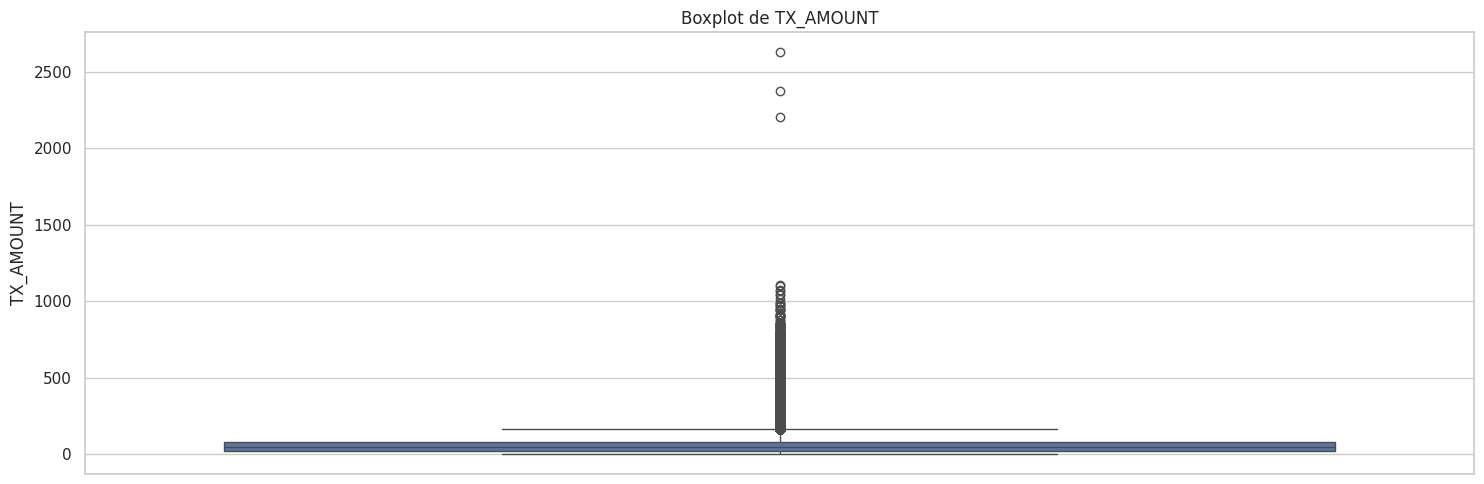

Número de outliers detectados con Isolation Forest: 16691


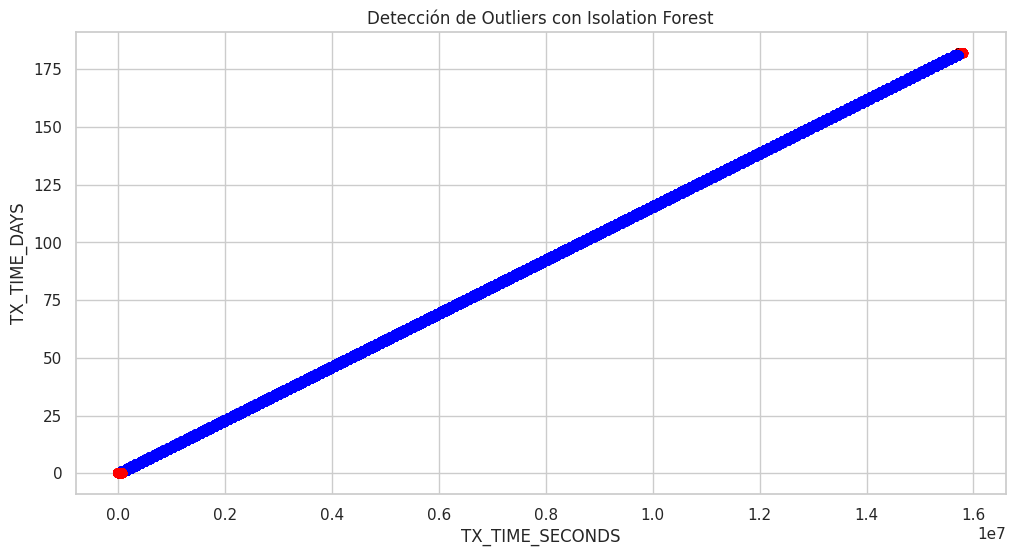

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#archivo original
df_original = pd.read_csv('fraudes.csv', parse_dates=['TX_DATETIME'])
#print(df_original[['TX_TIME_SECONDS', 'TX_TIME_DAYS']].describe())
numeric_cols = ['TX_AMOUNT']
df_numeric = df_original[numeric_cols]

#boxplots
plt.figure(figsize=(15, 5))
for i, col in enumerate(numeric_cols):
    plt.subplot(1, len(numeric_cols), i + 1)
    sns.boxplot(y=df_numeric[col])
    plt.title(f'Boxplot de {col}')
plt.tight_layout()
plt.show()

from sklearn.ensemble import IsolationForest
import numpy as np

#columnas a analizar
X_time = df_fraud[['TX_TIME_SECONDS', 'TX_TIME_DAYS']]

#predecir outliners
iso_forest = IsolationForest(contamination=0.01, random_state=42)  # 1% anomalías esperadas
iso_forest.fit(X_time)

df_fraud['outlier_time'] = iso_forest.predict(X_time)
# outlier_time = -1 es outlier, 1 es normal

print("Número de outliers detectados con Isolation Forest:", (df_fraud['outlier_time'] == -1).sum())

import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
plt.scatter(df_fraud['TX_TIME_SECONDS'], df_fraud['TX_TIME_DAYS'],
            c=df_fraud['outlier_time'].apply(lambda x: 'red' if x==-1 else 'blue'), alpha=0.3)
plt.xlabel('TX_TIME_SECONDS')
plt.ylabel('TX_TIME_DAYS')
plt.title('Detección de Outliers con Isolation Forest')
plt.show()


Exploración de relaciones entre variables

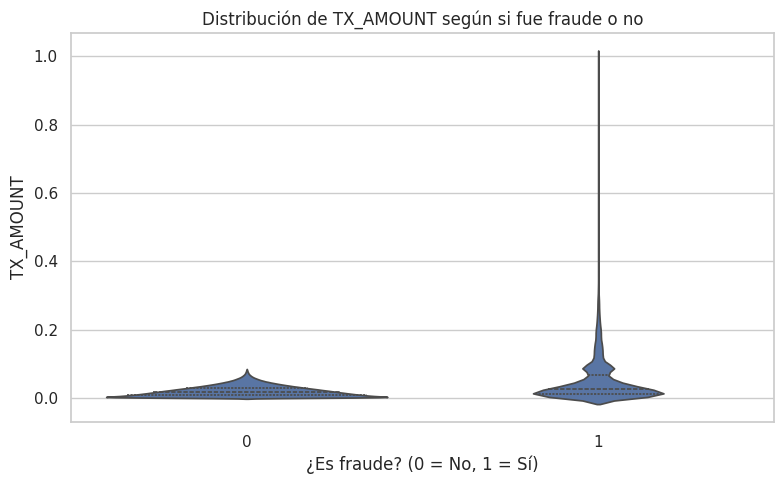

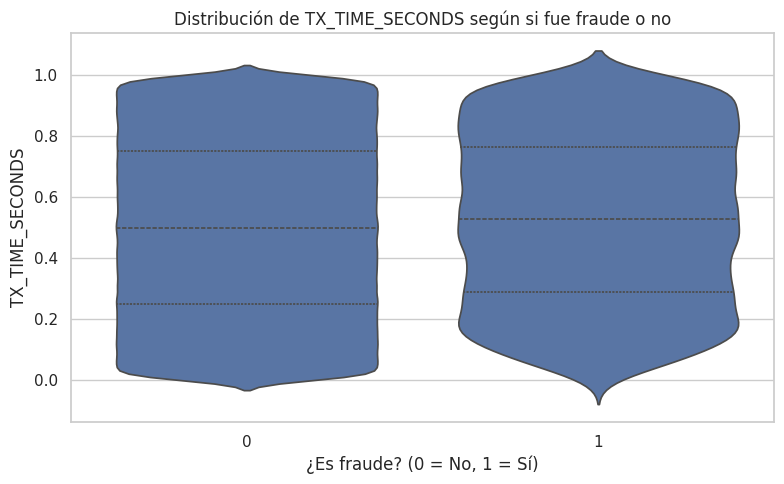

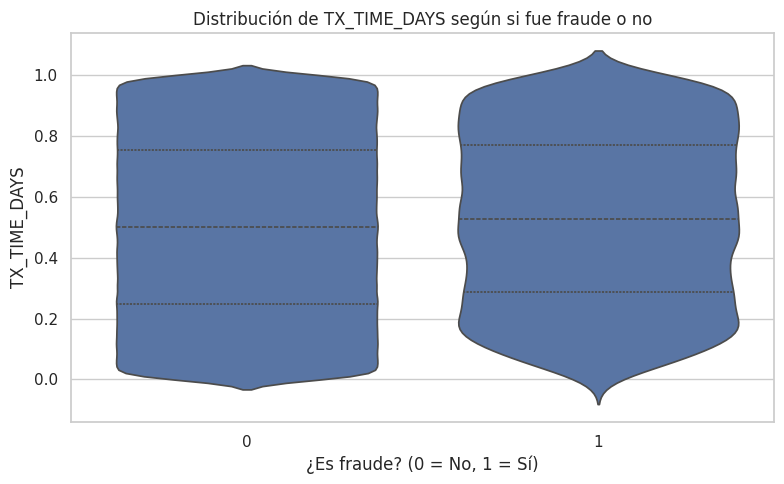

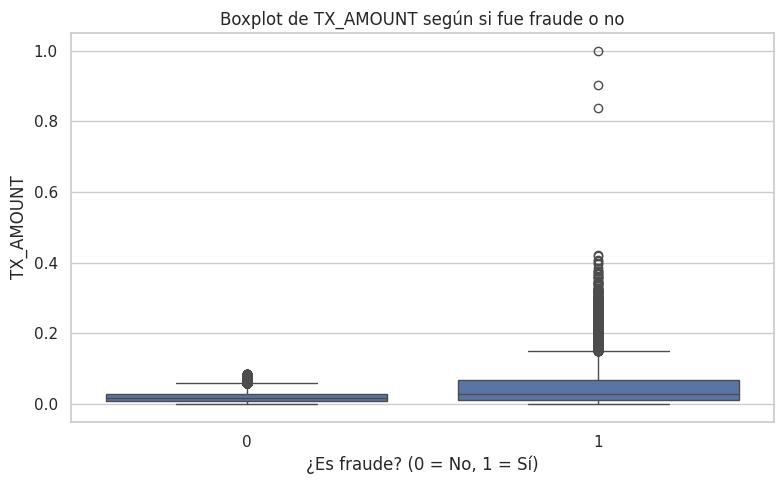

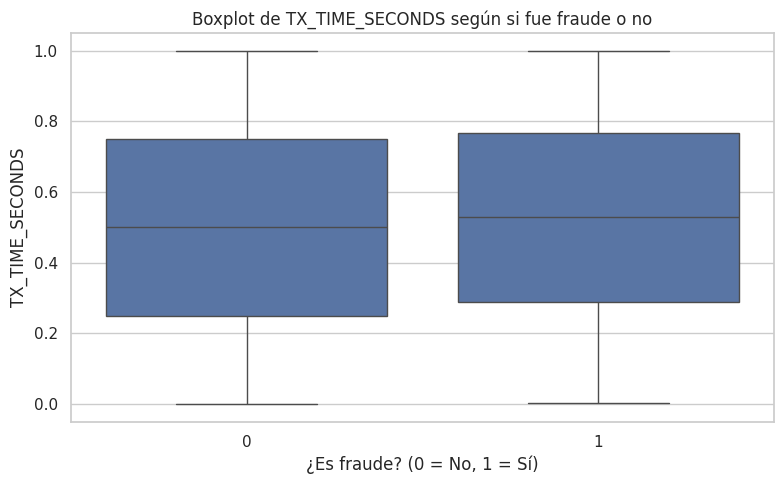

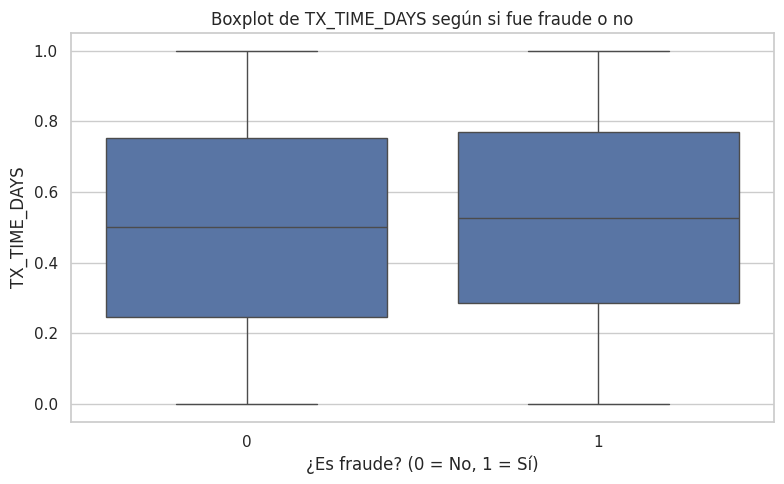

In [ ]:

import seaborn as sns
import matplotlib.pyplot as plt

#variables a comparar con TX_FRAUD
variables = ['TX_AMOUNT', 'TX_TIME_SECONDS', 'TX_TIME_DAYS']

#graf de violin
for var in variables:
    plt.figure(figsize=(8, 5))
    sns.violinplot(x='TX_FRAUD', y=var, data=df_fraud, inner='quartile')
    plt.title(f'Distribución de {var} según si fue fraude o no')
    plt.xlabel('¿Es fraude? (0 = No, 1 = Sí)')
    plt.ylabel(var)
    plt.tight_layout()
    plt.show()


segmentación de datos

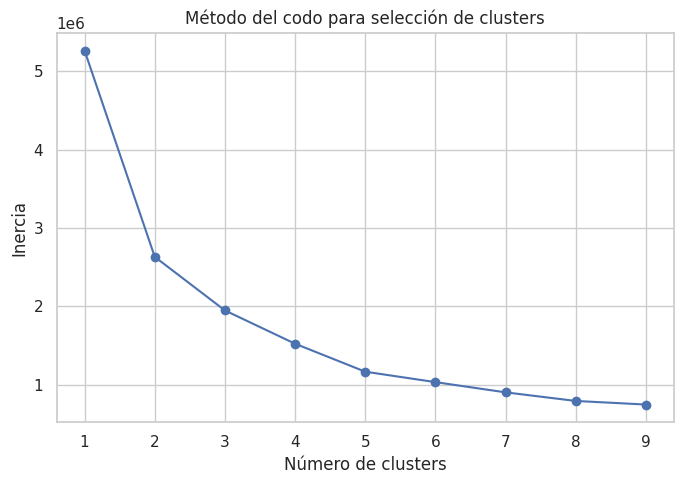

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Seleccionamos un subconjunto de columnas numéricas para agrupar
features = ['TX_AMOUNT', 'TX_TIME_SECONDS', 'TX_TIME_DAYS']
X = df_fraud[features]

# Normalizar (aunque ya estén normalizadas, esto es para asegurar uniformidad)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Usamos el método del codo para elegir número óptimo de clusters
inertia = []
k_range = range(1, 10)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Graficar el codo
plt.figure(figsize=(7, 5))
plt.plot(k_range, inertia, marker='o')
plt.title('Método del codo para selección de clusters')
plt.xlabel('Número de clusters')
plt.ylabel('Inercia')
plt.tight_layout()
plt.show()


<ipython-input-164-aed963a2921c>:9: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


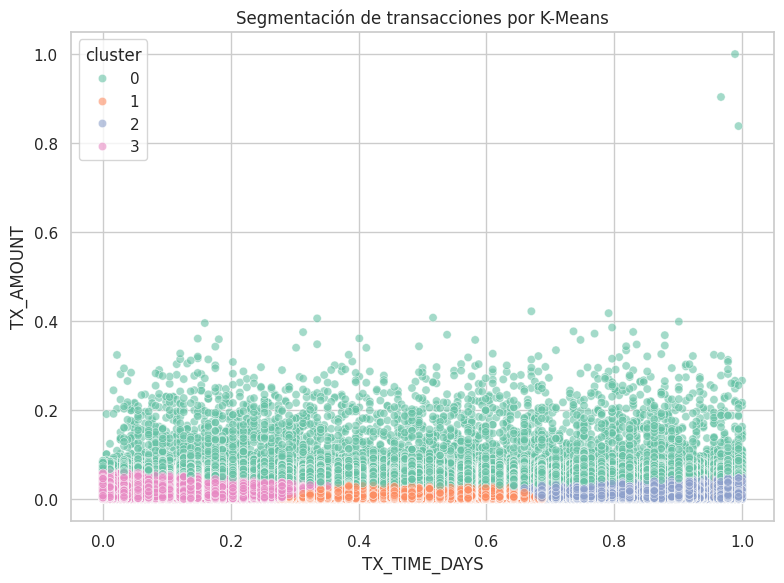

In [ ]:
#k clusters
kmeans = KMeans(n_clusters=3, random_state=42)
df_fraud['cluster'] = kmeans.fit_predict(X_scaled)

# Visualización en dos dimensiones (por ejemplo TX_AMOUNT vs TX_TIME_DAYS)
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_fraud, x='TX_TIME_DAYS', y='TX_AMOUNT', hue='cluster', palette='Set2', alpha=0.6)
plt.title('Segmentación de transacciones por K-Means')
plt.tight_layout()
plt.show()

Exploración de series temporales

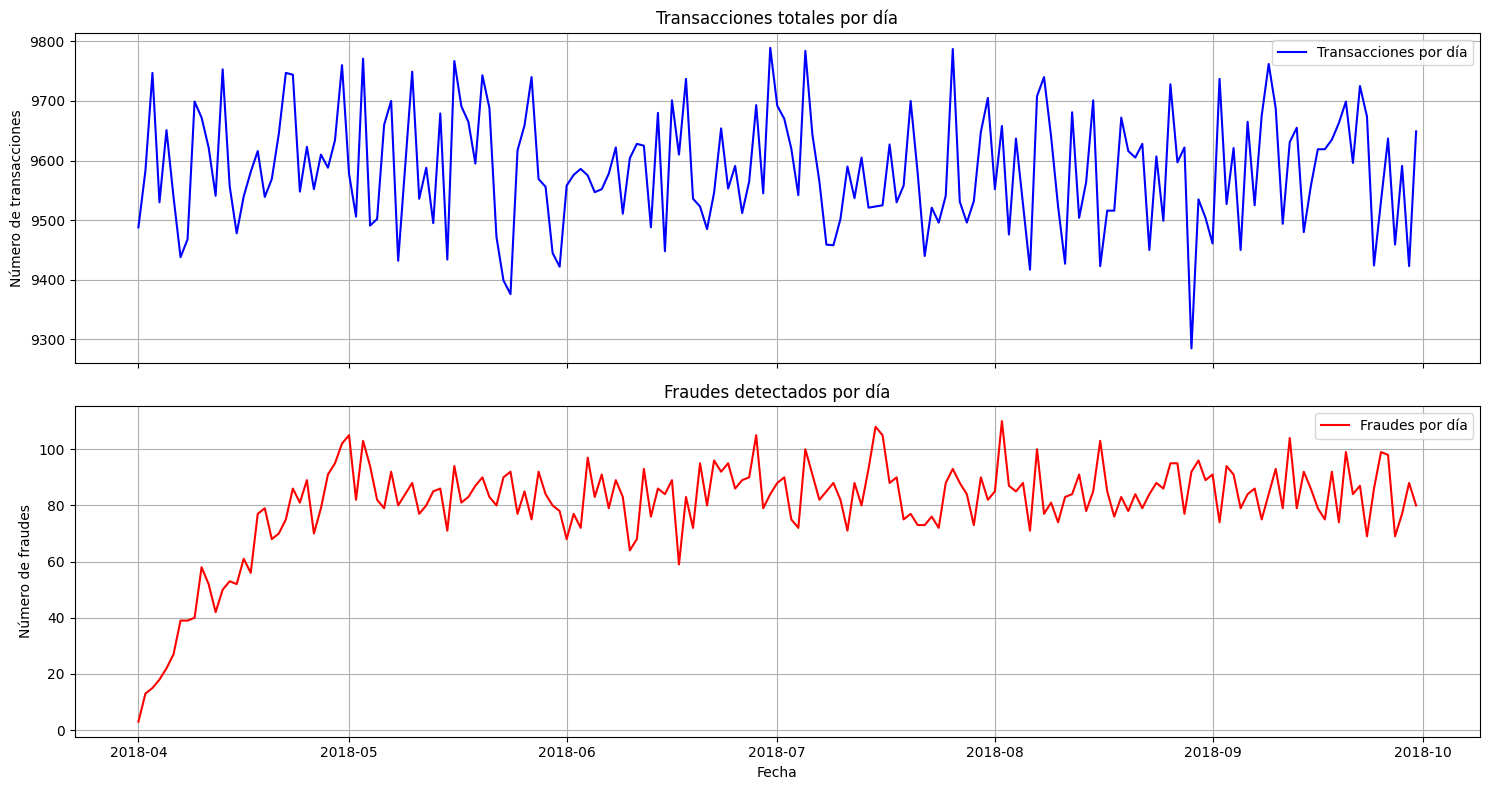

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

#cargar los datos con la columna de fechas en formato datetime
df_original = pd.read_csv('fraudes.csv', parse_dates=['TX_DATETIME'])
df_original = df_original.sort_values('TX_DATETIME') #orden
df_original['TX_DATE'] = df_original['TX_DATETIME'].dt.date #fecha sin hora

#transacciones p/dia
daily_tx = df_original.groupby('TX_DATE').size()

#fraudes p/dia
daily_fraud = df_original[df_original['TX_FRAUD'] == 1].groupby('TX_DATE').size()
daily_fraud = daily_tx.copy().apply(lambda x: 0)
daily_fraud.update(df_original[df_original['TX_FRAUD'] == 1].groupby('TX_DATE').size())


fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8), sharex=True)
#graf transacciones
ax1.plot(daily_tx.index, daily_tx.values, label='Transacciones por día', color='blue')
ax1.set_title('Transacciones totales por día')
ax1.set_ylabel('Número de transacciones')
ax1.grid(True)
ax1.legend()
#graf fraudes
ax2.plot(daily_fraud.index, daily_fraud.values, label='Fraudes por día', color='red')
ax2.set_title('Fraudes detectados por día')
ax2.set_xlabel('Fecha')
ax2.set_ylabel('Número de fraudes')
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()

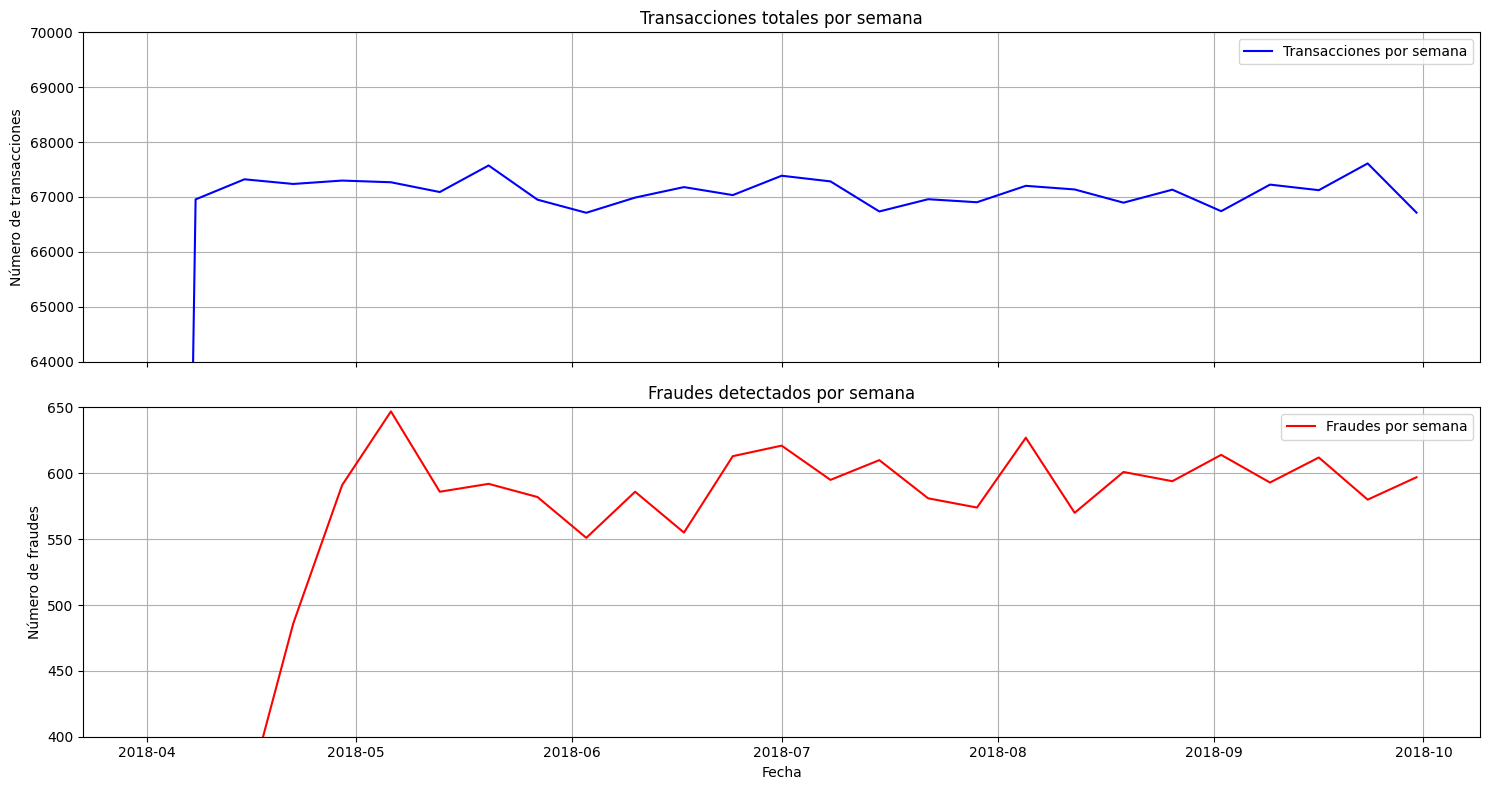

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Cargar datos y ordenar
df_original = pd.read_csv('fraudes.csv', parse_dates=['TX_DATETIME'])
df_original = df_original.sort_values('TX_DATETIME')

# Crear columna con fecha (sin hora)
df_original['TX_DATE'] = df_original['TX_DATETIME'].dt.date

# Convertir la columna TX_DATE a datetime (sin tiempo) para facilitar resampling
df_original['TX_DATE'] = pd.to_datetime(df_original['TX_DATE'])

# Agrupar por semana: usando resample semanal con fecha como índice
df_original.set_index('TX_DATE', inplace=True)

# Transacciones por semana
weekly_tx = df_original.resample('W').size()

# Fraudes por semana
weekly_fraud = df_original[df_original['TX_FRAUD'] == 1].resample('W').size()

# Graficar
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

# Transacciones por semana
ax1.plot(weekly_tx.index, weekly_tx.values, label='Transacciones por semana', color='blue')
ax1.set_title('Transacciones totales por semana')
ax1.set_ylabel('Número de transacciones')
ax1.grid(True)
ax1.set_ylim(64000,70000)
ax1.legend()

# Fraudes por semana
ax2.plot(weekly_fraud.index, weekly_fraud.values, label='Fraudes por semana', color='red')
ax2.set_title('Fraudes detectados por semana')
ax2.set_xlabel('Fecha')
ax2.set_ylabel('Número de fraudes')
ax2.set_ylim(400,700)
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()

## Modelado de datos

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import roc_curve, roc_auc_score, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

drop_cols = ['TX_FRAUD', 'TX_DATETIME', 'TX_FRAUD_SCENARIO'] #son atributos que indican si es fraude o no

### Para datos originales (sin remuestreo)

In [ ]:
features = [col for col in df_train.columns if col not in drop_cols]

X_train = df_train[features]
y_train = df_train['TX_FRAUD']
X_test = df_test[features]
y_test = df_test['TX_FRAUD']

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Para datos con ROS

In [ ]:
features = [col for col in df_train_ros.columns if col not in drop_cols]

X_train = df_train_ros[features]
y_train = df_train_ros['TX_FRAUD']
X_test = df_test_ros[features]
y_test = df_test_ros['TX_FRAUD']

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Para datos con SMOTE

In [ ]:
features = [col for col in df_train_smote.columns if col not in drop_cols]

X_train = df_train_smote[features]
y_train = df_train_smote['TX_FRAUD']
X_test = df_test_smote[features]
y_test = df_test_smote['TX_FRAUD']

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

NameError: name 'df_train_smote' is not defined

###Generar modelos

(Los modelos se generarán para los datos anteriores (SMOTE, ROS, sin muestreo, etc.) que se corrió al último)

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [21:34:01] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


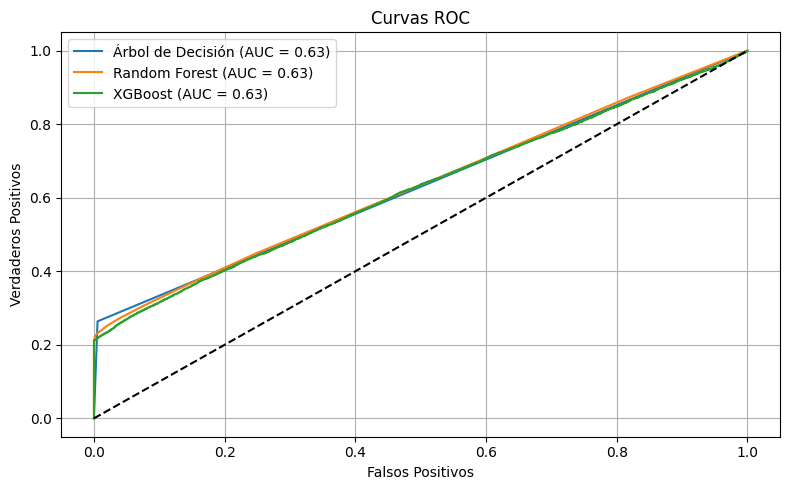

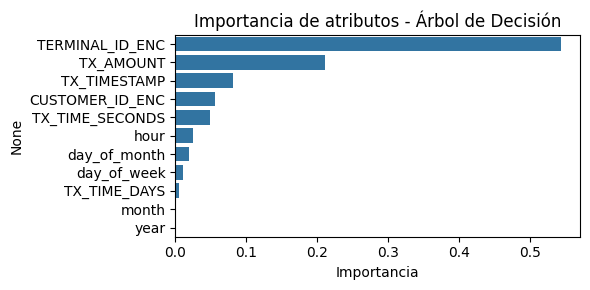

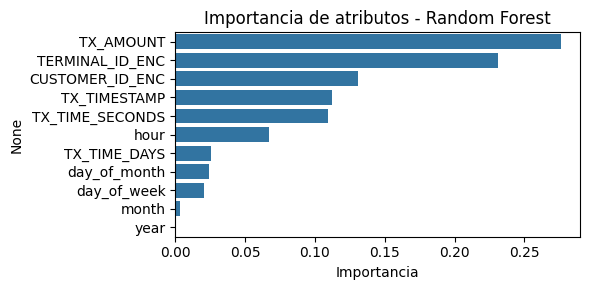

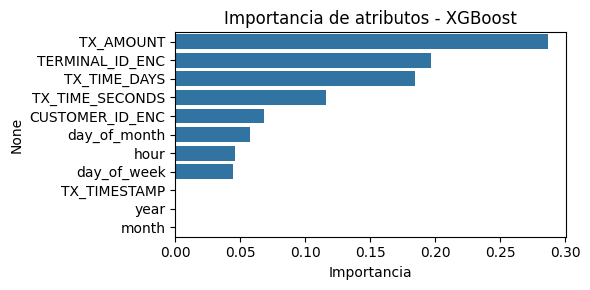

In [ ]:
modelos = {
    "Árbol de Decisión": DecisionTreeClassifier(random_state=0),
    "Random Forest": RandomForestClassifier(random_state=0),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=0)
}

resultados = {}
for nombre, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    y_prob = modelo.predict_proba(X_test)[:, 1]
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    resultados[nombre] = {'modelo': modelo, 'accuracy': acc, 'auc': auc, 'pred': y_pred, 'prob': y_prob}

# Curvas ROC
plt.figure(figsize=(8, 5))
for nombre, res in resultados.items():
    fpr, tpr, _ = roc_curve(y_test, res['prob'])
    plt.plot(fpr, tpr, label=f"{nombre} (AUC = {res['auc']:.2f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('Falsos Positivos')
plt.ylabel('Verdaderos Positivos')
plt.title('Curvas ROC')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# Importancia de atributos
for nombre, res in resultados.items():
    modelo = res['modelo']
    if hasattr(modelo, 'feature_importances_'):
        importancias = pd.Series(modelo.feature_importances_, index=features).sort_values(ascending=False)
        plt.figure(figsize=(6, 3))
        sns.barplot(x=importancias, y=importancias.index)
        plt.title(f"Importancia de atributos - {nombre}")
        plt.xlabel("Importancia")
        plt.tight_layout()
        plt.show()

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

modelo_dt = DecisionTreeClassifier(random_state=0)
modelo_dt.fit(X_train, y_train)
y_pred_dt = modelo_dt.predict(X_test)
y_prob_dt = modelo_dt.predict_proba(X_test)[:, 1]

print("Árbol de Decisión")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt):.2f}")
print(f"AUC: {roc_auc_score(y_test, y_prob_dt):.2f}")
print(f"F1-score: {f1_score(y_test, y_pred_dt):.2f}")

In [ ]:
modelo_rf = RandomForestClassifier(random_state=0)
modelo_rf.fit(X_train, y_train)
y_pred_rf = modelo_rf.predict(X_test)
y_prob_rf = modelo_rf.predict_proba(X_test)[:, 1]

print("Random Forest")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.2f}")
print(f"AUC: {roc_auc_score(y_test, y_prob_rf):.2f}")
print(f"F1-score: {f1_score(y_test, y_pred_rf):.2f}")

In [ ]:
from xgboost import XGBClassifier

modelo_xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=0)
modelo_xgb.fit(X_train, y_train)
y_pred_xgb = modelo_xgb.predict(X_test)
y_prob_xgb = modelo_xgb.predict_proba(X_test)[:, 1]

print("XGBoost")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.2f}")
print(f"AUC: {roc_auc_score(y_test, y_prob_xgb):.2f}")
print(f"F1-score: {f1_score(y_test, y_pred_xgb):.2f}")


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

resultados_modelos = {
    "Árbol de Decisión": {
        "Accuracy": accuracy_score(y_test, y_pred_dt),
        "AUC": roc_auc_score(y_test, y_prob_dt),
        "F1-score": f1_score(y_test, y_pred_dt)
    },
    "Random Forest": {
        "Accuracy": accuracy_score(y_test, y_pred_rf),
        "AUC": roc_auc_score(y_test, y_prob_rf),
        "F1-score": f1_score(y_test, y_pred_rf)
    },
    "XGBoost": {
        "Accuracy": accuracy_score(y_test, y_pred_xgb),
        "AUC": roc_auc_score(y_test, y_prob_xgb),
        "F1-score": f1_score(y_test, y_pred_xgb)
    }
}

df_resultados = pd.DataFrame(resultados_modelos).T
df_resultados = df_resultados.round(3)
df_resultados = df_resultados.sort_values("AUC", ascending=False)
print("Tabla comparativa de desempeño:")
print(df_resultados)

plt.figure(figsize=(6, 2))
sns.heatmap(df_resultados, annot=True, cmap="YlGnBu", fmt=".3f")
plt.title("Comparación de modelos para Base de datos desbalanceada")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns
import matplotlib.pyplot as plt

predicciones = {
    "Árbol de Decisión": y_pred_dt,
    "Random Forest": y_pred_rf,
    "XGBoost": y_pred_xgb
}

for nombre_modelo, y_pred in predicciones.items():
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=["No Fraude", "Fraude"],
                yticklabels=["No Fraude", "Fraude"])
    plt.xlabel('Predicción')
    plt.ylabel('Real')
    plt.title(f'Matriz de Confusión - {nombre_modelo}')
    plt.tight_layout()
    plt.show()


#### Hiperparametros distintos para SMOTE

In [ ]:
#otros hiperparametros
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

param_dt = {
    'max_depth': [6]  # diferente del default (None)
}

grid_dt = GridSearchCV(DecisionTreeClassifier(random_state=0), param_dt, cv=3, scoring='roc_auc')
grid_dt.fit(X_train, y_train)

y_pred_dt = grid_dt.predict(X_test)
y_prob_dt = grid_dt.predict_proba(X_test)[:, 1]


roc_dt = roc_auc_score(y_test, y_prob_dt)
acc_dt = accuracy_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_rf)

resultados_dt = {
    'modelo': 'DecisionTree',
    'hiperparam': 'max_depth=6',
    'roc': roc_dt,
    'acc': acc_dt,
    'f1': f1_dt
}

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

param_rf = {
    'max_depth': [10],  # diferente del default (None)
    'n_estimators': [150]  # diferente del default (100)
}

grid_rf = GridSearchCV(RandomForestClassifier(random_state=0), param_rf, cv=3, scoring='roc_auc')
grid_rf.fit(X_train, y_train)

y_pred_rf = grid_rf.predict(X_test)
y_prob_rf = grid_rf.predict_proba(X_test)[:, 1]

roc_rf = roc_auc_score(y_test, y_prob_rf)
acc_rf = accuracy_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

resultados_rf = {
    #'modelo': 'RandomForest',
    #'hiperparam': 'max_depth=10, n_estimators=150',
    'roc': roc_rf,
    'acc': acc_rf,
    'f1': f1_rf
}


In [ ]:
from xgboost import XGBClassifier

param_xgb = {
    'max_depth': [4],
    'n_estimators': [80],
    'learning_rate': [0.2]
}

grid_xgb = GridSearchCV(XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=0),
                        param_xgb, cv=3, scoring='roc_auc')
grid_xgb.fit(X_train, y_train)

y_pred_xgb = grid_xgb.predict(X_test)
y_prob_xgb = grid_xgb.predict_proba(X_test)[:, 1]

roc_xgb = roc_auc_score(y_test, y_prob_xgb)
acc_xgb = accuracy_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)

resultados_xgb = {
    #'modelo': 'XGBoost',
    #'hiperparam': 'max_depth=4, n_estimators=80, lr=0.2',
    'roc': roc_xgb,
    'acc': acc_xgb
    'f1': f1_xgb
}

In [ ]:
df_resultados_xgb = pd.DataFrame([resultados_xgb])
print(df_resultados_xgb)
df_resultados_rf = pd.DataFrame([resultados_rf])
print(df_resultados_rf)
df_resultados_dt = pd.DataFrame([resultados_dt])
print(df_resultados_dt)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

categorias = ['Árbol de Decisión', 'Random Forest', 'XGBoost']

grupo1 = [0.84, 0.93, 0.72]  # Datos del grupo 1
grupo2 = [ acc_dt,  acc_rf,  acc_xgb]  # Datos del grupo 2



x = np.arange(len(categorias))
ancho = 0.3  # ancho de cada barra


fig, ax = plt.subplots()
ax.bar(x - ancho, grupo1, width=ancho, label='Parámetros Default')
ax.bar(x, grupo2, width=ancho, label='Nuevos parámetros')


ax.set_xlabel('Modelos')
ax.set_ylabel('Accuracy')
ax.set_title('Gráfica de Accuracy para SMOTE')
ax.set_xticks(x)
ax.set_xticklabels(categorias)
ax.legend()

plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

categorias = ['Árbol de Decisión', 'Random Forest', 'XGBoost']

grupo1 = [0.84, 0.93, 0.72]  # Datos del grupo 1
grupo2 = [ f1_dt,  f1_rf,  f1_xgb]  # Datos del grupo 2



x = np.arange(len(categorias))
ancho = 0.3  # ancho de cada barra


fig, ax = plt.subplots()
ax.bar(x - ancho, grupo1, width=ancho, label='Parámetros Default')
ax.bar(x, grupo2, width=ancho, label='Nuevos parámetros')


ax.set_xlabel('Modelos')
ax.set_ylabel('F1 Score')
ax.set_title('Gráfica de F1 score para SMOTE')
ax.set_xticks(x)
ax.set_xticklabels(categorias)
ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

categorias = ['Árbol de Decisión', 'Random Forest', 'XGBoost']

grupo1 = [0.84, 0.98, 0.81]  # Datos del grupo 1
grupo2 = [roc_dt,  roc_rf,  roc_xgb]  # Datos del grupo 2



x = np.arange(len(categorias))
ancho = 0.3  # ancho de cada barra


fig, ax = plt.subplots()
ax.bar(x - ancho, grupo1, width=ancho, label='Parámetros Default')
ax.bar(x, grupo2, width=ancho, label='Nuevos parámetros')


ax.set_xlabel('Modelos')
ax.set_ylabel('AC ROC')
ax.set_title('Gráfica de ROC para SMOTE')
ax.set_xticks(x)
ax.set_xticklabels(categorias)
ax.legend()

plt.tight_layout()
plt.show()